# HW 1: Classic ML Text Classification

News topic classification on lenta-ru-news with bag-of-words and TF-IDF.

## Setup

1. Install [uv](https://docs.astral.sh/uv/getting-started/installation/)
2. `uv sync` from repo root
3. `uv run jupyter notebook`
4. Dataset downloads automatically on first run


In [1]:
import os

os.chdir(os.path.join(os.path.dirname(os.getcwd()), "") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

# Always work from repo root
REPO_ROOT = os.getcwd()
print(f"Working directory: {REPO_ROOT}")
assert os.path.exists("pyproject.toml"), "Run this notebook from the repo root or the notebooks/ folder"

Working directory: /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course


### Imports


In [2]:
import os
import re
import math
import random
import string
import warnings
import multiprocessing

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from joblib import Parallel, delayed, dump

import razdel
import pymorphy3
from corus import load_lenta
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

N_JOBS = multiprocessing.cpu_count()
print(f"Imports OK | CPU cores: {N_JOBS}")

# Hardware detection (sklearn is CPU-only; GPU useful if switching to PyTorch models)
try:
    import torch
    if torch.backends.mps.is_available():
        print("GPU: Apple MPS available (use torch for GPU-accelerated models)")
    elif torch.cuda.is_available():
        print(f"GPU: CUDA — {torch.cuda.get_device_name(0)}")
    else:
        print("GPU: torch installed but no GPU detected")
except ImportError:
    print("GPU: torch not installed — sklearn pipelines run on CPU (n_jobs parallelism only)")

# Cache paths — checked here so all downstream cells can branch on them
INTERIM_PATH  = os.path.join(REPO_ROOT, "data", "interim",   "hw_1", "df_preprocessed.parquet")
PROCESSED_DIR = os.path.join(REPO_ROOT, "data", "processed", "hw_1")
INTERIM_EXISTS = os.path.exists(INTERIM_PATH)
SPLITS_EXIST   = all(
    os.path.exists(os.path.join(PROCESSED_DIR, f"{s}.parquet"))
    for s in ("train", "val", "test")
)
print(f"Interim cache : {'HIT' if INTERIM_EXISTS else 'MISS'}")
print(f"Splits  cache : {'HIT' if SPLITS_EXIST  else 'MISS'}")

Imports OK | CPU cores: 12
GPU: torch not installed — sklearn pipelines run on CPU (n_jobs parallelism only)
Interim cache : MISS
Splits  cache : MISS


/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading


In [3]:
RAW_DATA_PATH = os.path.join(REPO_ROOT, "data", "raw", "hw_1", "lenta-ru-news.csv.gz")

if not os.path.exists(RAW_DATA_PATH):
    import urllib.request
    url = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"
    print(f"Downloading dataset to {RAW_DATA_PATH}...")
    os.makedirs(os.path.dirname(RAW_DATA_PATH), exist_ok=True)
    urllib.request.urlretrieve(url, RAW_DATA_PATH)
    print("Done.")
else:
    print(f"Dataset already exists at {RAW_DATA_PATH}")

Dataset already exists at /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/data/raw/hw_1/lenta-ru-news.csv.gz


In [4]:
if not INTERIM_EXISTS:
    records = []
    for record in load_lenta(RAW_DATA_PATH):
        records.append({"title": record.title, "text": record.text, "topic": record.topic})
    df_full = pd.DataFrame(records)
    print(f"Total records loaded: {len(df_full):,}")
    display(df_full.head())
else:
    print("Skipping raw CSV load — interim cache hit")

Total records loaded: 739,351


,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


## 2. Data Preparation

### Sampling

Take a stratified 100k sample to keep class proportions.


In [5]:
if not INTERIM_EXISTS:
    SAMPLE_SIZE = 100_000

    df_full = df_full.dropna(subset=["title", "text", "topic"])
    df_full = df_full[df_full["text"].str.strip().astype(bool)].reset_index(drop=True)

    print(f"Records after cleaning nulls/empties: {len(df_full):,}")
    print(f"Number of unique topics: {df_full['topic'].nunique()}")
    print()
    print(df_full["topic"].value_counts())

Records after cleaning nulls/empties: 739,346
Number of unique topics: 24

topic
Россия               160516
Мир                  136679
Экономика             79538
Спорт                 64421
Культура              53802
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
                        203
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


In [6]:
if not INTERIM_EXISTS:
    samples = []
    for topic, group in df_full.groupby("topic"):
        n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_full)))
        samples.append(group.sample(n=n, random_state=RANDOM_STATE))

    df = pd.concat(samples).reset_index(drop=True)
    if len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

    print(f"Sampled dataset size: {len(df):,}")
    print()
    print(df["topic"].value_counts())

Sampled dataset size: 99,987

topic
Россия               21710
Мир                  18486
Экономика            10757
Спорт                 8713
Культура              7276
Бывший СССР           7222
Наука и техника       7186
Интернет и СМИ        6042
Из жизни              3734
Дом                   2939
Силовые структуры     2650
Ценности              1050
Бизнес                1000
Путешествия            866
69-я параллель         171
Крым                    90
Культпросвет            45
                        27
Легпром                 15
Библиотека               8
Name: count, dtype: int64


In [7]:
# Load df from cache or use the freshly sampled one from above
if INTERIM_EXISTS:
    df = pd.read_parquet(INTERIM_PATH)
    print(f"Loaded preprocessed data from cache: {len(df):,} rows")
    print(f"Columns: {list(df.columns)}")
else:
    print(f"Using freshly sampled df: {len(df):,} rows")

Using freshly sampled df: 99,987 rows


### EDA


In [8]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print(df[["text_len", "word_count"]].describe())

           text_len    word_count
count  99987.000000  99987.000000
mean    1334.893756    180.433666
std      553.690590     74.098350
min        3.000000      1.000000
25%      977.000000    132.000000
50%     1256.000000    170.000000
75%     1604.000000    217.000000
max    14257.000000   1871.000000


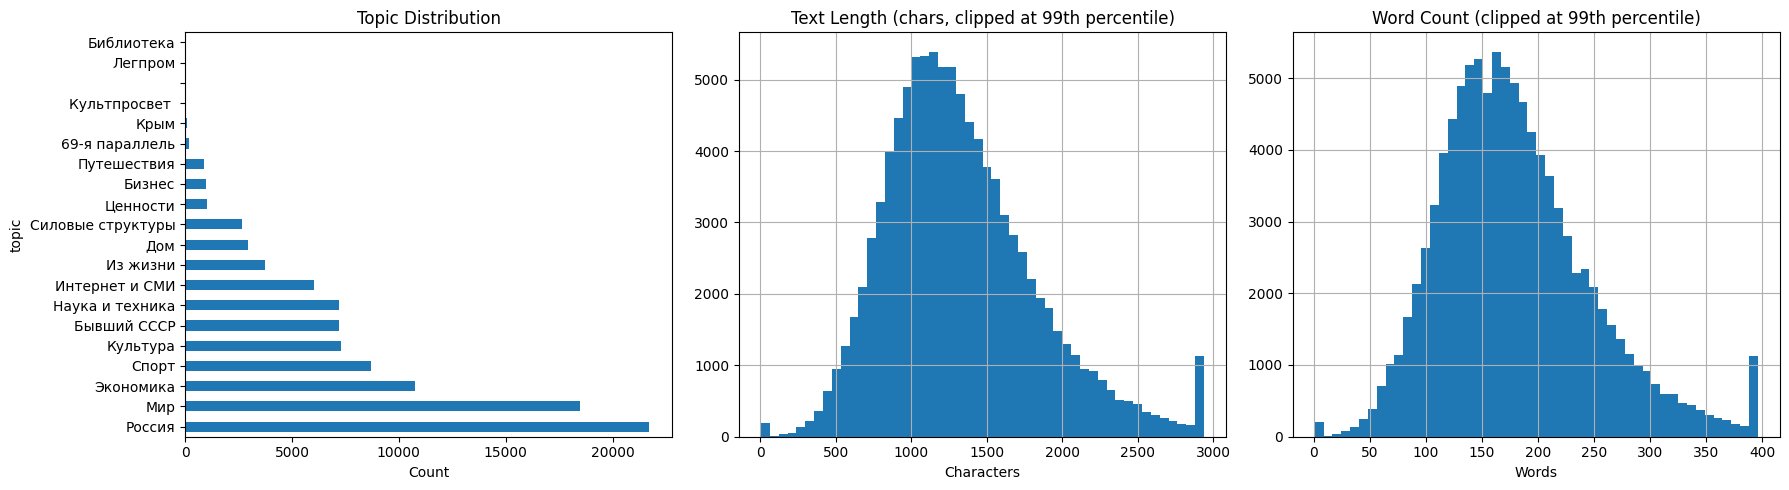

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Topic distribution
df["topic"].value_counts().plot.barh(ax=axes[0])
axes[0].set_title("Topic Distribution")
axes[0].set_xlabel("Count")

# Text length distribution
df["text_len"].clip(upper=df["text_len"].quantile(0.99)).hist(bins=50, ax=axes[1])
axes[1].set_title("Text Length (chars, clipped at 99th percentile)")
axes[1].set_xlabel("Characters")

# Word count distribution
df["word_count"].clip(upper=df["word_count"].quantile(0.99)).hist(bins=50, ax=axes[2])
axes[2].set_title("Word Count (clipped at 99th percentile)")
axes[2].set_xlabel("Words")

plt.tight_layout()
plt.show()

### Data quality check

Following lecture best practices: check duplicates, conflicting labels, bad texts, and outliers.


In [10]:
# Duplicates
n_dup = df.duplicated("text").sum()
print(f"Duplicate texts: {n_dup}")

# Conflicting labels: same text, different topic
n_conflict = (df.groupby("text")["topic"].nunique() > 1).sum()
print(f"Texts with conflicting topic labels: {n_conflict}")

# Drop duplicates, keeping first occurrence
df = df.drop_duplicates("text").reset_index(drop=True)
print(f"After dedup: {len(df):,}")

Duplicate texts: 88
Texts with conflicting topic labels: 14
After dedup: 99,899


In [11]:
# Bad texts: empty, only punctuation/symbols, only digits
def is_bad_text(s):
    s0 = s.strip()
    if len(s0) == 0:
        return True
    if re.fullmatch(r"[^a-zA-Za-z\u0400-\u04FF]+", s0):
        return True
    if re.fullmatch(r"\d+", s0):
        return True
    return False

bad_mask = df["text"].apply(is_bad_text)
print(f"Bad texts: {bad_mask.sum()} ({bad_mask.mean():.2%})")
df = df[~bad_mask].reset_index(drop=True)


Bad texts: 0 (0.00%)


In [12]:
# Length outliers (clip at 99.5th percentile)
upper = df["word_count"].quantile(0.995)
too_long = df["word_count"] > upper
print(f"Texts longer than {upper:.0f} words: {too_long.sum()}")
df = df[~too_long].reset_index(drop=True)
print(f"Clean dataset: {len(df):,}")


Texts longer than 445 words: 494
Clean dataset: 99,405


In [13]:
# Compile regex patterns once (main process only)
RE_URL      = re.compile(r"https?://\S+|www\.\S+")
RE_EMAIL    = re.compile(r"\S+@\S+\.\S+")
RE_NONALPHA = re.compile(r"[^a-zA-Z\u0400-\u04FF\s]")
RE_MULTISPACE = re.compile(r"\s+")


def preprocess_text(text, morph=None):
    """Full preprocessing pipeline. Uses module-level morph if not provided."""
    if morph is None:
        morph = pymorphy3.MorphAnalyzer()
    text = text.lower()
    text = RE_URL.sub(" ", text)
    text = RE_EMAIL.sub(" ", text)
    text = RE_NONALPHA.sub(" ", text)
    text = RE_MULTISPACE.sub(" ", text).strip()
    tokens = [token.text for token in razdel.tokenize(text)]
    lemmas = [morph.parse(tok)[0].normal_form for tok in tokens if len(tok) >= 2]
    return " ".join(lemmas)


def preprocess_chunk(texts):
    """Worker function: one MorphAnalyzer per chunk (amortises ~30 MB init cost)."""
    import re, razdel, pymorphy3  # re-import inside worker (spawn on macOS)
    _morph    = pymorphy3.MorphAnalyzer()
    _url      = re.compile(r"https?://\S+|www\.\S+")
    _email    = re.compile(r"\S+@\S+\.\S+")
    _nonalpha = re.compile(r"[^a-zA-Z\u0400-\u04FF\s]")
    _multi    = re.compile(r"\s+")
    out = []
    for text in texts:
        text = text.lower()
        text = _url.sub(" ", text)
        text = _email.sub(" ", text)
        text = _nonalpha.sub(" ", text)
        text = _multi.sub(" ", text).strip()
        tokens = [t.text for t in razdel.tokenize(text)]
        lemmas = [_morph.parse(tok)[0].normal_form for tok in tokens if len(tok) >= 2]
        out.append(" ".join(lemmas))
    return out


# Smoke-test
_sample = preprocess_text("Хакеры раскрыли планы: https://example.com и email@test.ru")
print("Smoke test:", _sample)

Smoke test: хакер раскрыть план


In [14]:
if not INTERIM_EXISTS:
    df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    texts = df["full_text"].tolist()

    # Split into N_JOBS chunks so each worker process creates one MorphAnalyzer
    chunk_size = math.ceil(len(texts) / N_JOBS)
    chunks = [texts[i : i + chunk_size] for i in range(0, len(texts), chunk_size)]

    print(f"Parallel preprocessing: {len(texts):,} texts across {len(chunks)} workers ...")
    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(preprocess_chunk)(chunk) for chunk in tqdm(chunks, desc="Chunks")
    )
    df["processed_text"] = [t for chunk in results for t in chunk]
    print("Done.")
else:
    print("Skipping preprocessing — processed_text loaded from cache")

Parallel preprocessing: 99,405 texts across 12 workers ...


Chunks: 100%|█████████████████████████| 12/12 [00:00<00:00, 406.23it/s]


Done.


In [15]:
if not INTERIM_EXISTS:
    empty_mask = df["processed_text"].str.strip() == ""
    print(f"Empty texts after preprocessing: {empty_mask.sum()}")
    df = df[~empty_mask].reset_index(drop=True)
    print(f"Final dataset size: {len(df):,}")

Empty texts after preprocessing: 0
Final dataset size: 99,405


In [16]:
if not INTERIM_EXISTS:
    os.makedirs(os.path.dirname(INTERIM_PATH), exist_ok=True)
    df.to_parquet(INTERIM_PATH, index=False)
    print(f"Saved preprocessed data to {INTERIM_PATH}")

Saved preprocessed data to /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/data/interim/hw_1/df_preprocessed.parquet


In [17]:
if SPLITS_EXIST:
    train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
    val_df   = pd.read_parquet(os.path.join(PROCESSED_DIR, "val.parquet"))
    test_df  = pd.read_parquet(os.path.join(PROCESSED_DIR, "test.parquet"))
    X_train, y_train = train_df["processed_text"], train_df["topic"]
    X_val,   y_val   = val_df["processed_text"],   val_df["topic"]
    X_test,  y_test  = test_df["processed_text"],  test_df["topic"]
    print("Loaded splits from cache")
else:
    X = df["processed_text"]
    y = df["topic"]
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
    )
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    for name, X_part, y_part in [("train", X_train, y_train),
                                  ("val",   X_val,   y_val),
                                  ("test",  X_test,  y_test)]:
        pd.DataFrame({"processed_text": X_part, "topic": y_part}).to_parquet(
            os.path.join(PROCESSED_DIR, f"{name}.parquet"), index=False
        )

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 59,643  Val: 19,881  Test: 19,881


## 3. Dummy Baseline

Most-frequent class predictor as a sanity check.


In [18]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)
print(f"Dummy baseline accuracy: {accuracy_score(y_val, y_pred_dummy):.4f}")
print(f"Dummy baseline F1 (macro): {f1_score(y_val, y_pred_dummy, average='macro', zero_division=0):.4f}")
print()


Dummy baseline accuracy: 0.2168
Dummy baseline F1 (macro): 0.0178



## 4. LogisticRegression with Two Vectorizers

### CountVectorizer


In [19]:
pipe_count = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
        n_jobs=N_JOBS,
    )),
])

pipe_count.fit(X_train, y_train)

y_pred_count = pipe_count.predict(X_val)
print("=== CountVectorizer + LogisticRegression ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_count):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_count, average='macro'):.4f}")
print()
print(classification_report(y_val, y_pred_count))

=== CountVectorizer + LogisticRegression ===
Accuracy: 0.8022
F1 (macro): 0.5862

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         6
   69-я параллель       1.00      0.47      0.64        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.63      0.38      0.47       195
      Бывший СССР       0.82      0.82      0.82      1417
              Дом       0.84      0.78      0.81       582
         Из жизни       0.60      0.56      0.58       746
   Интернет и СМИ       0.75      0.71      0.73      1205
             Крым       0.86      0.33      0.48        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.86      0.87      0.87      1449
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.81      0.79      3685
  Наука и техника       0.83      0.82      0.83      1427
      Путешествия       0.77    

### TfidfVectorizer

TF-IDF downweights common terms, usually helps for topic classification.


In [20]:
pipe_tfidf = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
        n_jobs=N_JOBS,
    )),
])

pipe_tfidf.fit(X_train, y_train)

y_pred_tfidf = pipe_tfidf.predict(X_val)
print("=== TfidfVectorizer + LogisticRegression ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred_tfidf):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_tfidf, average='macro'):.4f}")
print()
print(classification_report(y_val, y_pred_tfidf))

=== TfidfVectorizer + LogisticRegression ===
Accuracy: 0.8118
F1 (macro): 0.5182

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         6
   69-я параллель       0.00      0.00      0.00        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.89      0.16      0.27       195
      Бывший СССР       0.83      0.81      0.82      1417
              Дом       0.88      0.75      0.81       582
         Из жизни       0.67      0.53      0.59       746
   Интернет и СМИ       0.78      0.71      0.74      1205
             Крым       1.00      0.06      0.11        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.88      0.86      1449
          Легпром       0.00      0.00      0.00         3
              Мир       0.79      0.85      0.82      3685
  Наука и техника       0.83      0.86      0.84      1427
      Путешествия       0.84    

## 5. Hyperparameter Tuning

RandomizedSearchCV with 3-fold stratified CV. Tuning vocab size, ngram range, frequency thresholds, and regularization.


In [21]:
param_distributions = {
    "vectorizer__max_features": [10000, 30000, 50000, 100000, None],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [1, 2, 5],
    "vectorizer__max_df": [0.8, 0.9, 1.0],
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [22]:
search_count = RandomizedSearchCV(
    pipe_count,
    param_distributions,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
)

search_count.fit(X_train, y_train)

print(f"Best CountVectorizer F1 (macro): {search_count.best_score_:.4f}")
print(f"Best params: {search_count.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CountVectorizer F1 (macro): 0.5838
Best params: {'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 2, 'vectorizer__max_features': 50000, 'vectorizer__max_df': 0.8, 'classifier__C': 10.0}


In [23]:
search_tfidf = RandomizedSearchCV(
    pipe_tfidf,
    param_distributions,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
)

search_tfidf.fit(X_train, y_train)

print(f"Best TfidfVectorizer F1 (macro): {search_tfidf.best_score_:.4f}")
print(f"Best params: {search_tfidf.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best TfidfVectorizer F1 (macro): 0.5689
Best params: {'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 2, 'vectorizer__max_features': 50000, 'vectorizer__max_df': 0.8, 'classifier__C': 10.0}


In [24]:
# Compare on val
best_count = search_count.best_estimator_
best_tfidf = search_tfidf.best_estimator_

for name, model in [("CountVec (tuned)", best_count), ("TfidfVec (tuned)", best_tfidf)]:
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    print(f"{name}: Accuracy={acc:.4f}, F1(macro)={f1:.4f}")

CountVec (tuned): Accuracy=0.8070, F1(macro)=0.5951
TfidfVec (tuned): Accuracy=0.8241, F1(macro)=0.5958


## 6. Test Evaluation and Error Analysis


In [25]:
# Pick best model
val_f1_count = f1_score(y_val, best_count.predict(X_val), average="macro")
val_f1_tfidf = f1_score(y_val, best_tfidf.predict(X_val), average="macro")

if val_f1_tfidf >= val_f1_count:
    best_model = best_tfidf
    best_name = "TfidfVectorizer"
else:
    best_model = best_count
    best_name = "CountVectorizer"

print(f"Best model: {best_name}")

# Test set evaluation
y_pred_test = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test F1 (macro): {f1_score(y_test, y_pred_test, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_test))

Best model: TfidfVectorizer
Test Accuracy: 0.8271
Test F1 (macro): 0.5692

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         5
   69-я параллель       0.80      0.24      0.36        34
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.60      0.28      0.38       196
      Бывший СССР       0.84      0.84      0.84      1417
              Дом       0.88      0.80      0.84       581
         Из жизни       0.67      0.59      0.62       746
   Интернет и СМИ       0.79      0.73      0.76      1206
             Крым       1.00      0.11      0.20        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.87      0.89      0.88      1450
          Легпром       0.00      0.00      0.00         3
              Мир       0.81      0.84      0.82      3686
  Наука и техника       0.85      0.86      0.85      1427
      Путешествия       0.84      0.60 

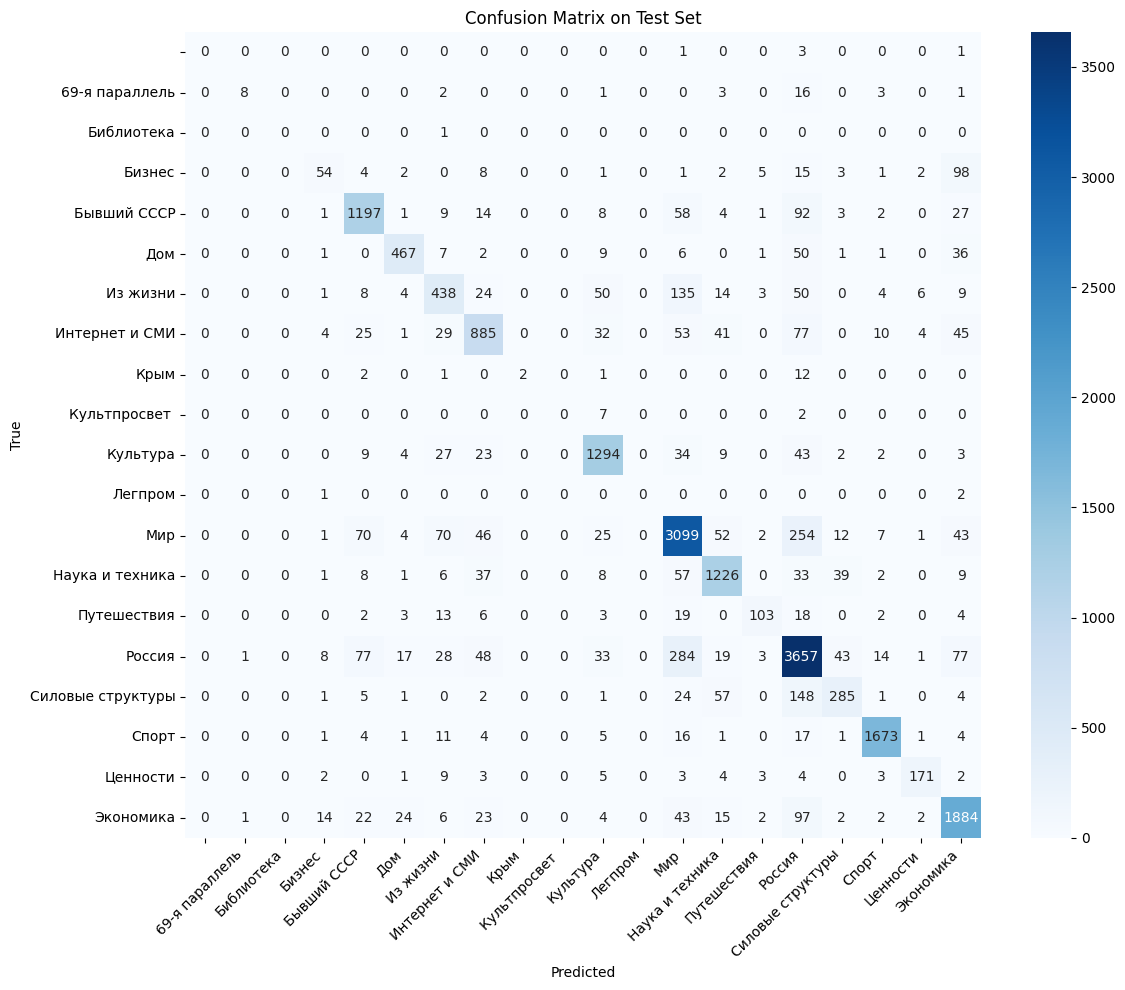

In [26]:
# Confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Error analysis
errors = pd.DataFrame({
    "text": X_test.values,
    "true_topic": y_test.values,
    "pred_topic": y_pred_test,
})
errors = errors[errors["true_topic"] != errors["pred_topic"]]

print(f"Total misclassified: {len(errors)} ({len(errors)/len(y_test):.1%})")
print()


confusion_pairs = errors.groupby(["true_topic", "pred_topic"]).size().sort_values(ascending=False)
print("Top 10 confusion pairs (true -> predicted):")
print(confusion_pairs.head(10))

Total misclassified: 3438 (17.3%)

Top 10 confusion pairs (true -> predicted):
true_topic         pred_topic 
Россия             Мир            284
Мир                Россия         254
Силовые структуры  Россия         148
Из жизни           Мир            135
Бизнес             Экономика       98
Экономика          Россия          97
Бывший СССР        Россия          92
Интернет и СМИ     Россия          77
Россия             Бывший СССР     77
                   Экономика       77
dtype: int64


In [28]:
# Examples from top confusion pair
top_pair = confusion_pairs.index[0]
print(f"Examples misclassified as '{top_pair[1]}' instead of '{top_pair[0]}':\n")

pair_errors = errors[(errors["true_topic"] == top_pair[0]) & (errors["pred_topic"] == top_pair[1])]
for _, row in pair_errors.head(3).iterrows():
    print(f"Text: {row['text'][:150]}...")
    print()

Examples misclassified as 'Мир' instead of 'Россия':

Text: швейцарский полиция найти конопляный поле благодаря google earth швейцарский полицейский обнаружить крупный плантация конопля помощь картографический ...

Text: жертва пожар на завод ломо стать два человек жертва пожар на территория завод ломо санкт петербург стать по малый мера два человек сообщать фонтанка р...

Text: семь человек пострадать результат авария на месторождение газпром ямало ненецкий автономный округ результат авария на месторождение газпром пострадать...



In [29]:
# Save weights
import joblib

weights_dir = os.path.join(REPO_ROOT, "weights", "hw_1")
os.makedirs(weights_dir, exist_ok=True)

weights_path = os.path.join(weights_dir, "best_pipeline.joblib")
joblib.dump(best_model, weights_path)
print(f"Saved best model weights to {weights_path}")


Saved best model weights to /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/weights/hw_1/best_pipeline.joblib


## Conclusions

| Model | Val F1 (macro) | Test F1 (macro) |
|-------|---------------|----------------|
| Dummy | ~ low | ~ low |
| CountVec + LR | see above | - |
| TfidfVec + LR | see above | - |
| CountVec + LR (tuned) | see above | - |
| TfidfVec + LR (tuned) | see above | see above |

Both vectorizers crush the dummy baseline. TF-IDF generally edges out raw counts by downweighting ubiquitous words. Tuning helps moderately -- bigrams and vocab size matter most. Most errors happen between overlapping topics (politics vs economy). Lemmatization is key for Russian.
